In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/pima-indians-diabetes-database/diabetes.csv


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv("/kaggle/input/pima-indians-diabetes-database/diabetes.csv")

In [5]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [7]:
df.duplicated().sum()

0

In [8]:
df.shape

(768, 9)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [10]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [11]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

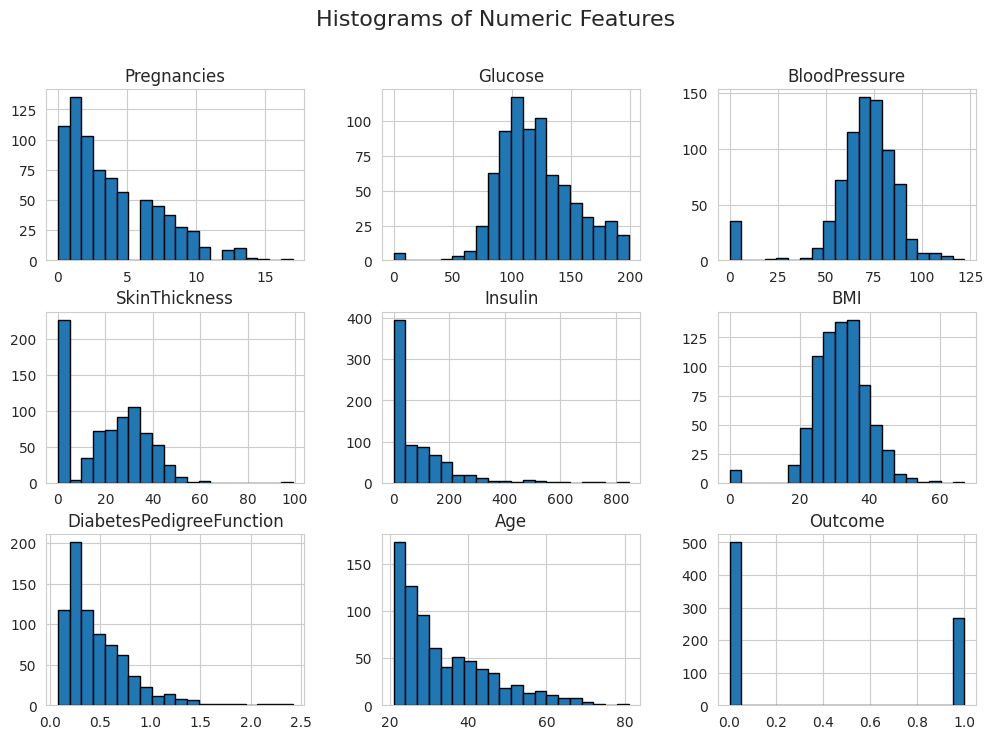

In [12]:
# Set the style for seaborn
sns.set_style("whitegrid")

# 1. Histogram for all numeric columns
df.hist(figsize=(12, 8), bins=20, edgecolor='black')
plt.suptitle("Histograms of Numeric Features", fontsize=16)
plt.show()

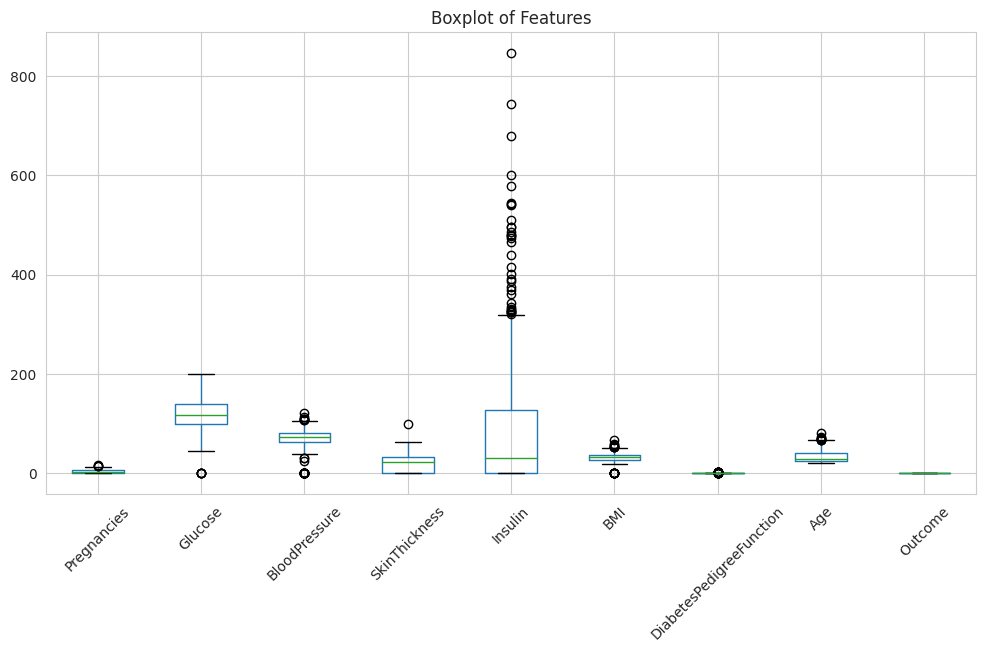

In [13]:
# 2. Boxplot for all numeric columns
plt.figure(figsize=(12, 6))
df.boxplot()
plt.title("Boxplot of Features")
plt.xticks(rotation=45)
plt.show()

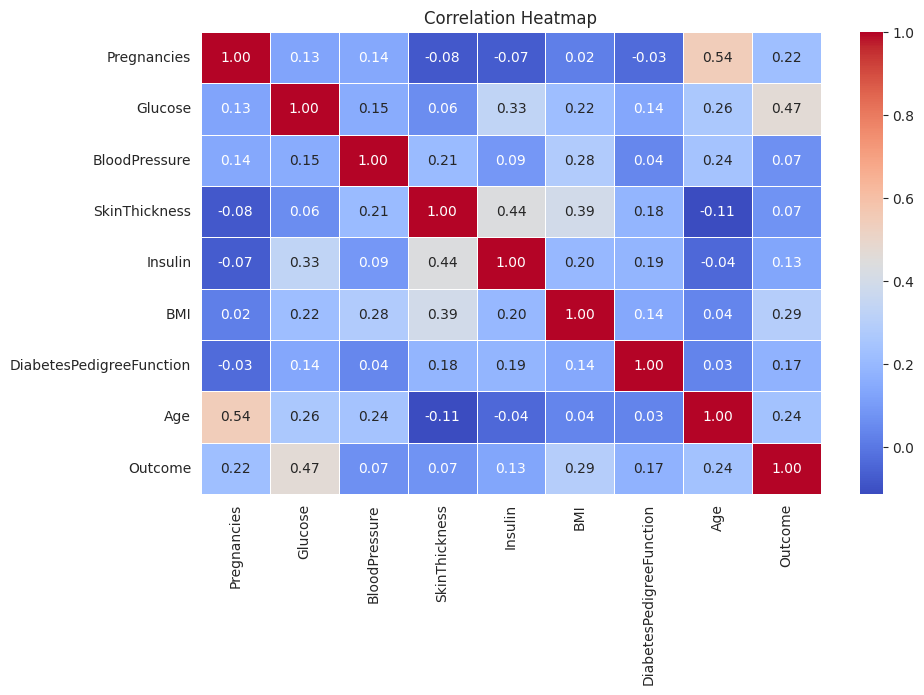

In [15]:
# 4. Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

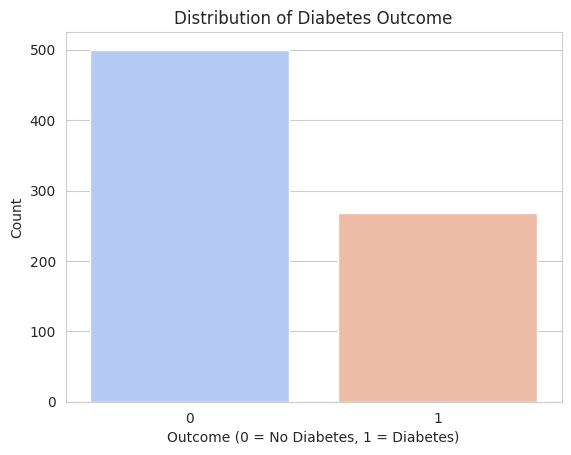

In [16]:
# 5. Countplot for Outcome distribution
sns.countplot(x=df["Outcome"], palette="coolwarm")
plt.title("Distribution of Diabetes Outcome")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Count")
plt.show()

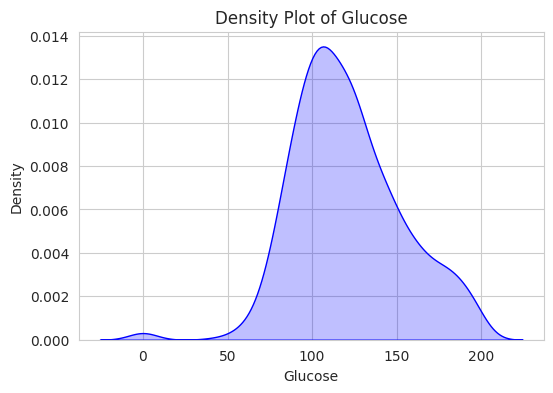

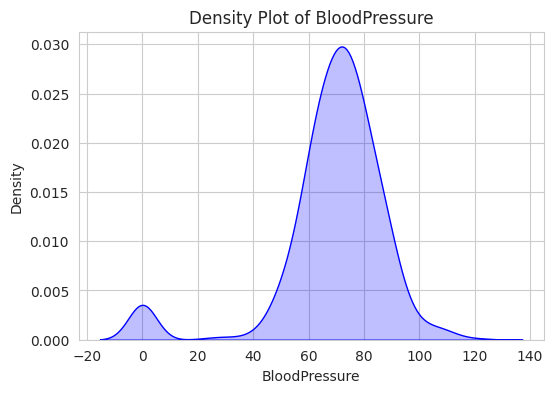

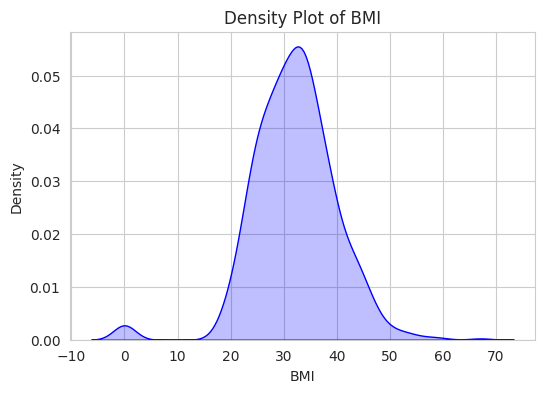

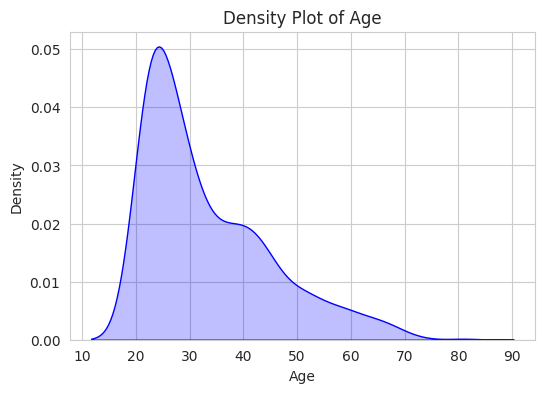

In [17]:
# 6-9. KDE Plots for numerical variables
features = ["Glucose", "BloodPressure", "BMI", "Age"]
for feature in features:
    plt.figure(figsize=(6, 4))
    sns.kdeplot(df[feature], shade=True, color="blue")
    plt.title(f"Density Plot of {feature}")
    plt.xlabel(feature)
    plt.show()

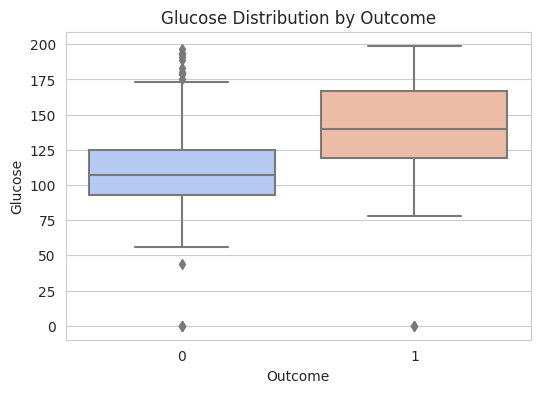

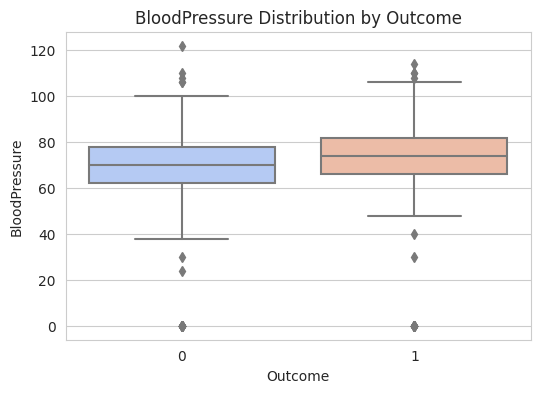

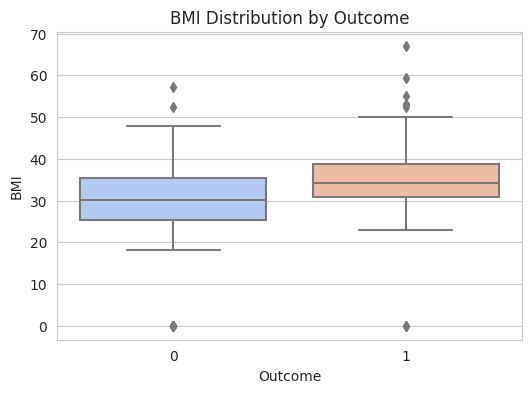

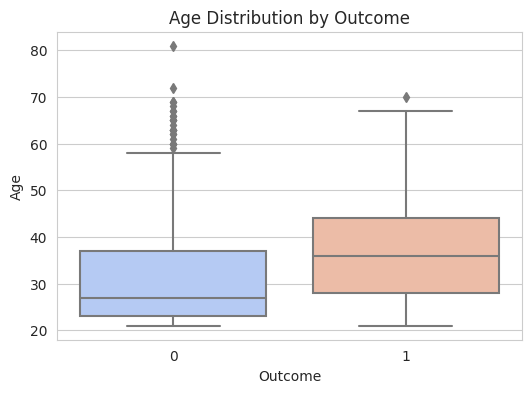

In [18]:
# 10-13. Boxplots for numeric features grouped by Outcome
for feature in features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x="Outcome", y=feature, data=df, palette="coolwarm")
    plt.title(f"{feature} Distribution by Outcome")
    plt.show()

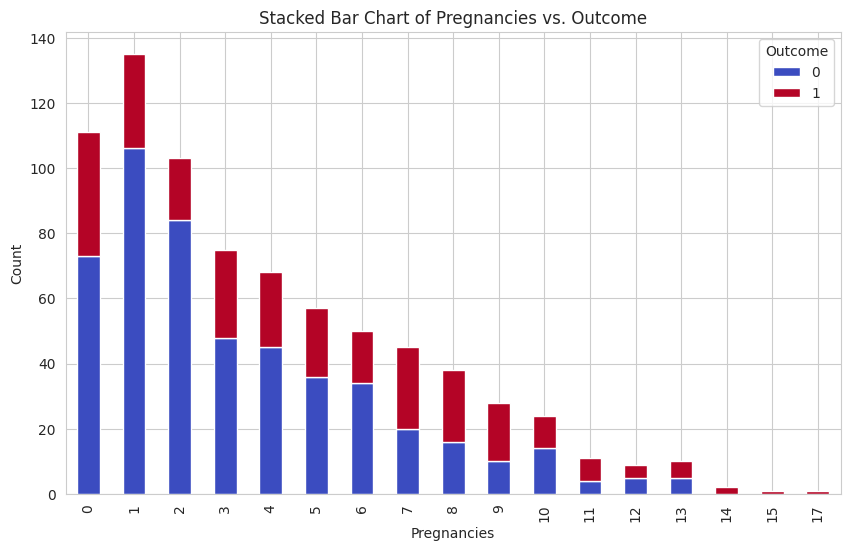

In [26]:
# 24. Stacked bar plot for Outcome vs. Pregnancies
cross_tab = pd.crosstab(df['Pregnancies'], df['Outcome'])
cross_tab.plot(kind='bar', stacked=True, figsize=(10, 6), colormap="coolwarm")
plt.title("Stacked Bar Chart of Pregnancies vs. Outcome")
plt.ylabel("Count")
plt.xlabel("Pregnancies")
plt.show()

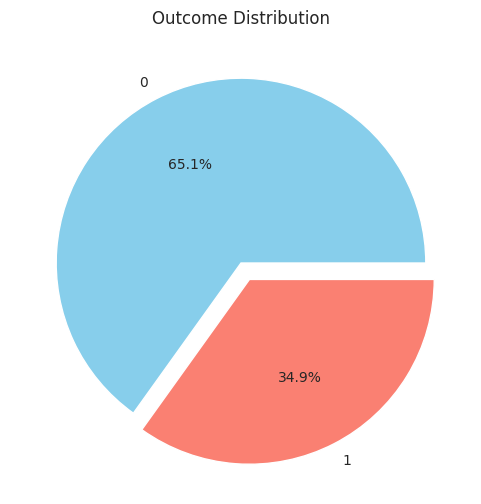

In [27]:
# 25. Pie chart for Outcome
plt.figure(figsize=(6, 6))
df["Outcome"].value_counts().plot.pie(autopct='%1.1f%%', colors=["skyblue", "salmon"], explode=[0, 0.1])
plt.title("Outcome Distribution")
plt.ylabel("")
plt.show()

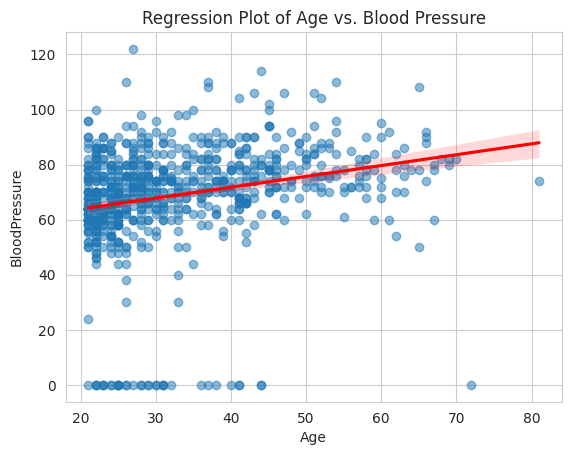

In [31]:
# 29. Regression plot for BloodPressure vs. Age
sns.regplot(x="Age", y="BloodPressure", data=df, scatter_kws={'alpha':0.5}, line_kws={"color": "red"})
plt.title("Regression Plot of Age vs. Blood Pressure")
plt.show()

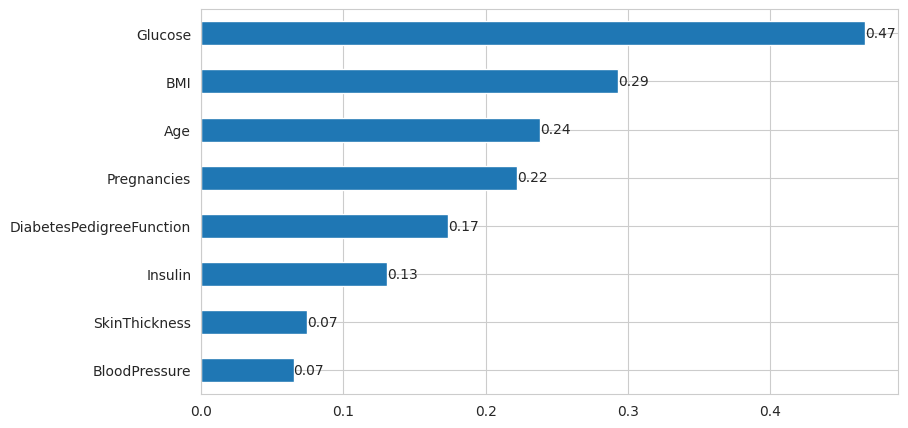

In [33]:
plt.figure(figsize=(9,5))
ax = df.corr()["Outcome"].drop("Outcome").sort_values().plot.barh()
ax.bar_label(ax.containers[0], fmt='%.2f');


In [34]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb
import lightgbm as lgb


In [35]:
# Step 5: Define features (X) and target (y)
X = df.drop("Outcome", axis=1)  # Features
y = df["Outcome"]  # Target variable

# Step 6: Normalize the dataset
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 7: Split the dataset into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

In [36]:
# Step 8: Initialize models
models = {
    "Logistic Regression": LogisticRegression(),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Support Vector Machine": SVC(probability=True),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Naive Bayes": GaussianNB(),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss"),
    "LightGBM": lgb.LGBMClassifier()
}

In [37]:
# Step 9: Train and evaluate models
model_results = {}

for name, model in models.items():
    print(f"Training {name}...")
    
    # Step 10: Train the model
    model.fit(X_train, y_train)
    
    # Step 11: Make predictions
    y_pred = model.predict(X_test)
    
    # Step 12: Evaluate model performance
    accuracy = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    model_results[name] = [accuracy, auc]
    
    # Step 13: Print classification report
    print(f"\n{name} - Accuracy: {accuracy:.4f}, AUC: {auc:.4f}")
    print(classification_report(y_test, y_pred))
    print("-" * 50)

# Step 14: Convert results to DataFrame
results_df = pd.DataFrame(model_results, index=["Accuracy", "AUC"]).T
results_df = results_df.sort_values(by="Accuracy", ascending=False)


Training Logistic Regression...

Logistic Regression - Accuracy: 0.7143, AUC: 0.8230
              precision    recall  f1-score   support

           0       0.76      0.82      0.79       100
           1       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154

--------------------------------------------------
Training K-Nearest Neighbors...

K-Nearest Neighbors - Accuracy: 0.7078, AUC: 0.7458
              precision    recall  f1-score   support

           0       0.76      0.80      0.78       100
           1       0.59      0.54      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.70      0.71      0.70       154

--------------------------------------------------
Training Decision Tree...

Decision Tree - Accuracy: 0.7143, AUC: 0.6565
 


Model Performance Comparison:
                         Accuracy       AUC
AdaBoost                0.759740  0.814444
LightGBM                0.759740  0.814630
Gradient Boosting       0.753247  0.842222
Support Vector Machine  0.746753  0.793333
XGBoost                 0.746753  0.805556
Random Forest           0.746753  0.817685
Decision Tree           0.714286  0.656481
Logistic Regression     0.714286  0.822963
K-Nearest Neighbors     0.707792  0.745833
Naive Bayes             0.707792  0.772778


Text(0.5, 1.0, 'Model Accuracy Comparison')

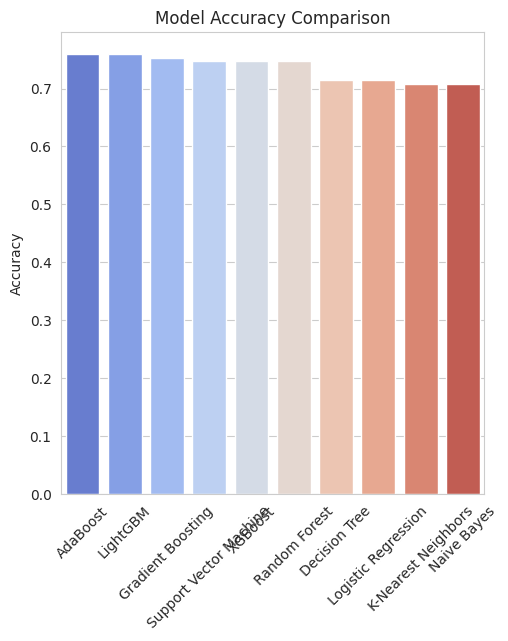

In [38]:
# Step 15: Display model performance comparison
print("\nModel Performance Comparison:\n", results_df)

# Step 16: Plot Accuracy and AUC Scores
plt.figure(figsize=(12, 6))

# Step 17: Bar plot for Accuracy
plt.subplot(1, 2, 1)
sns.barplot(x=results_df.index, y=results_df["Accuracy"], palette="coolwarm")
plt.xticks(rotation=45)
plt.title("Model Accuracy Comparison")

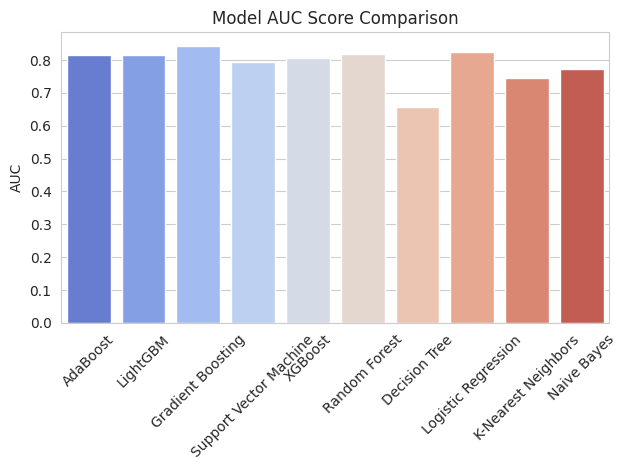

In [39]:
# Step 18: Bar plot for AUC
plt.subplot(1, 1, 1)
sns.barplot(x=results_df.index, y=results_df["AUC"], palette="coolwarm")
plt.xticks(rotation=45)
plt.title("Model AUC Score Comparison")

plt.tight_layout()
plt.show()

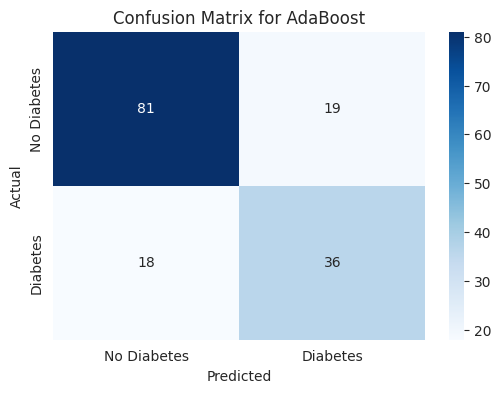

In [40]:
# Step 19: Display Confusion Matrix for Best Model
best_model_name = results_df.index[0]
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, fmt="d", cmap="Blues", xticklabels=["No Diabetes", "Diabetes"], yticklabels=["No Diabetes", "Diabetes"])
plt.title(f"Confusion Matrix for {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [41]:
# Step 20: Save the best model
import joblib
joblib.dump(best_model, "best_diabetes_model.pkl")
print(f"\nBest Model ({best_model_name}) saved successfully!")


Best Model (AdaBoost) saved successfully!
